<a href="https://www.kaggle.com/code/sangplanetdestroyer/notebook-p2-vision-dan-deep?scriptVersionId=354901082" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/sangplanetdestroyer/notebook-p2-vision-dan-deep?scriptVersionId=354898879" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# P2 - Transfer Learning untuk Klasifikasi Tanaman UAV

Notebook ini mengadaptasi materi ResNet18 untuk dataset InterDuPa-UAV: Durian dan Papaya. Tiga strategi dilatih dengan split yang sama: feature extraction, partial fine-tuning, dan scratch. Jalankan seluruh sel secara berurutan di Kaggle atau lokal.

## 1. Konfigurasi

Pada Kaggle, atur `DATASET_ROOT` ke folder input yang berisi dua folder kelas dan metadata. Dataset ini tidak menyediakan pemetaan crop ke citra UAV sumber, sehingga eksperimen ini menggunakan stratified image split sebagai fallback. Split ini reproducible, tetapi belum dapat menjamin bebas data leakage.

In [1]:
from pathlib import Path
import copy
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import StratifiedGroupKFold, StratifiedShuffleSplit
from torch import nn, optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

SEED = 42
BATCH_SIZE = 32
EPOCHS = 10
VAL_FRACTION = 0.20
NUM_WORKERS = 0

KAGGLE_DATASET_ROOT = Path('/kaggle/input/datasets/sangplanetdestroyer/dataset-p2-vision-dan-deep/datasets')
DATASET_ROOT = KAGGLE_DATASET_ROOT if KAGGLE_DATASET_ROOT.exists() else Path('datasets')
METADATA_PATH = DATASET_ROOT / 'Dataset-metadata.xlsx'
# Dataset ini tidak punya pemetaan ke sumber citra; jadi pakai stratified image split sebagai fallback seperti yang dijelaskan.
GROUP_MAPPING_PATH = None
GROUP_PATH_COLUMN = 'relative_path'
GROUP_ID_COLUMN = 'group_id'
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
RESULTS_DIR = OUTPUT_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Dataset root: {DATASET_ROOT.resolve()}')

Device: cuda
Dataset root: /kaggle/input/datasets/sangplanetdestroyer/dataset-p2-vision-dan-deep/datasets


## 2. Pemeriksaan dataset dan metadata


In [2]:
CLASS_DIRS = {
    'Durian': 'Durian (durio zibethinus)',
    'Papaya': 'Papaya (carica papaya)',
}
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f'Dataset root not found: {DATASET_ROOT}')

records = []
for label, folder_name in CLASS_DIRS.items():
    class_dir = DATASET_ROOT / folder_name
    if not class_dir.exists():
        raise FileNotFoundError(f'Missing class directory: {class_dir}')
    records.extend({'path': path, 'label_name': label} for path in class_dir.rglob('*')
                   if path.suffix.lower() in IMAGE_EXTENSIONS)

df = pd.DataFrame(records).sort_values('path').reset_index(drop=True)
class_to_idx = {name: index for index, name in enumerate(CLASS_DIRS)}
df['label'] = df['label_name'].map(class_to_idx)
print(df.groupby('label_name').size().rename('images'))
print(f'Total images before blind holdout: {len(df)}')

# Sisihkan blind test yang seimbang dulu sebelum membuat split train/validation.
# Model tidak akan pernah menerima label tersembunyi dari dataframe ini.
BLIND_TEST_PER_CLASS = 20
blind_test_df = (df.groupby('label_name', group_keys=False)
                   .sample(n=BLIND_TEST_PER_CLASS, random_state=SEED)
                   .sort_index()
                   .reset_index(drop=True))
blind_indices = set(blind_test_df['path'])
df = df[~df['path'].isin(blind_indices)].reset_index(drop=True)
print(f'Blind test holdout: {len(blind_test_df)} images ({BLIND_TEST_PER_CLASS} per class)')
print(f'Images available for train/validation: {len(df)}')

if METADATA_PATH.exists():
    metadata = pd.read_excel(METADATA_PATH)
    display(metadata.head(10))
    print('Metadata columns:', metadata.columns.tolist())
else:
    print(f'Warning: metadata file not found at {METADATA_PATH}')

label_name
Durian    3327
Papaya    2872
Name: images, dtype: int64
Total images before blind holdout: 6199
Blind test holdout: 40 images (20 per class)
Images available for train/validation: 6159


,Family,Label,Example,Other value,Other value.1,Other value.2,Other value.3
0,Dataset identification,Title of the dataset,InterDuPa-UAV: A UAV-based Dataset for the Cla...,NaN,NaN,NaN,NaN
1,NaN,Abstract,This dataset includes intercropped durian (dur...,NaN,NaN,NaN,NaN
2,NaN,Purpose,This dataset serves as a valuable resource for...,NaN,NaN,NaN,NaN
3,NaN,Keywords (theme),Intercropped/Durian/Papaya/UAV/Image processin...,NaN,NaN,NaN,NaN
4,NaN,Keywords (location),Vietnam/Hau Giang/Chau Thanh,NaN,NaN,NaN,NaN
5,NaN,Keywords (discipline),Agricultural Sciences/Remote Sensing/Robotics,NaN,NaN,NaN,NaN
6,NaN,Creation date of the dataset (dd/mm/year),20/09/2023,NaN,NaN,NaN,NaN
7,NaN,Status (completed or ongoing),Completed,NaN,NaN,NaN,NaN
8,NaN,Type,"Image dataset (raw, labelled)",NaN,NaN,NaN,NaN
9,NaN,Language,English,NaN,NaN,NaN,NaN


Metadata columns: ['Family', 'Label', 'Example', 'Other value', 'Other value.1', 'Other value.2', 'Other value.3']


## 3. Pembagian data train/validation berbasis citra (fallback)


In [3]:
def make_split(frame):
    y = frame['label'].to_numpy()
    if GROUP_MAPPING_PATH is not None:
        mapping_path = Path(GROUP_MAPPING_PATH)
        if not mapping_path.exists():
            raise FileNotFoundError(f'Group mapping not found: {mapping_path}')
        mapping = pd.read_csv(mapping_path)
        required = {GROUP_PATH_COLUMN, GROUP_ID_COLUMN}
        if not required.issubset(mapping.columns):
            raise ValueError(f'Group mapping must contain {required}; found {mapping.columns.tolist()}')
        work = frame.copy()
        work['relative_path'] = work['path'].map(lambda value: str(value.relative_to(DATASET_ROOT)))
        work = work.merge(mapping[[GROUP_PATH_COLUMN, GROUP_ID_COLUMN]], left_on='relative_path',
                          right_on=GROUP_PATH_COLUMN, how='left', validate='one_to_one')
        if work[GROUP_ID_COLUMN].isna().any():
            missing = work.loc[work[GROUP_ID_COLUMN].isna(), 'relative_path'].head().tolist()
            raise ValueError(f'Unmapped images in group mapping, for example: {missing}')
        groups = work[GROUP_ID_COLUMN].astype(str).to_numpy()
        splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
        train_idx, val_idx = next(splitter.split(work, y, groups))
        assert set(groups[train_idx]).isdisjoint(set(groups[val_idx])), 'Group leakage detected'
        print(f'Group split: {len(set(groups))} source groups, with no group overlap.')
        return train_idx, val_idx

    print('WARNING: source group mapping is unavailable. Using the documented stratified image split fallback.')
    print('Split ini reproducible, tapi hasilnya belum bisa diklaim bebas leakage antar-citra dari sumber UAV.')
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRACTION, random_state=SEED)
    return next(splitter.split(frame, y))

train_idx, val_idx = make_split(df)
assert not set(train_idx).intersection(val_idx)
train_df, val_df = df.iloc[train_idx].reset_index(drop=True), df.iloc[val_idx].reset_index(drop=True)
split_summary = pd.concat(
    [train_df.assign(split='train'), val_df.assign(split='validation')],
    ignore_index=True,
)
display(pd.crosstab(
    split_summary['split'],
    split_summary['label_name'],
    normalize='index',
))
print(f'Train: {len(train_df)} | Validation: {len(val_df)}')

Split ini reproducible, tapi hasilnya belum bisa diklaim bebas leakage antar-citra dari sumber UAV.


label_name,Durian,Papaya
split,,
train,0.536838,0.463162
validation,0.537338,0.462662


Train: 4927 | Validation: 1232


## 4. Augmentasi, preprocessing, dan dataloader


In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
valid_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class UAVPlantDataset(Dataset):
    def __init__(self, frame, transform):
        self.paths = frame['path'].tolist()
        self.labels = frame['label'].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        with Image.open(self.paths[index]) as image:
            image = image.convert('RGB')
        return self.transform(image), self.labels[index]

loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=device.type == 'cuda')
train_loader = DataLoader(UAVPlantDataset(train_df, train_transform), shuffle=True, **loader_kwargs)
val_loader = DataLoader(UAVPlantDataset(val_df, valid_transform), shuffle=False, **loader_kwargs)
class_names = list(CLASS_DIRS)
print(class_names)

['Durian', 'Papaya']


## 5. ResNet18 dan utilitas training

In [5]:
def build_model(strategy):
    if strategy == 'scratch':
        model = models.resnet18(weights=None)
    else:
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, len(class_names))

    if strategy == 'feature_extraction':
        for parameter in model.parameters():
            parameter.requires_grad = False
        for parameter in model.fc.parameters():
            parameter.requires_grad = True
        optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
    elif strategy == 'partial_fine_tuning':
        for parameter in model.parameters():
            parameter.requires_grad = False
        for module in (model.layer4, model.fc):
            for parameter in module.parameters():
                parameter.requires_grad = True
        optimizer = optim.Adam([
            {'params': model.layer4.parameters(), 'lr': 1e-4},
            {'params': model.fc.parameters(), 'lr': 1e-3},
        ])
    elif strategy == 'scratch':
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
    else:
        raise ValueError(f'Unknown strategy: {strategy}')
    return model.to(device), optimizer

def run_epoch(model, dataloader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    losses, predictions, targets = [], [], []
    for images, labels in tqdm(dataloader, leave=False):
        images, labels = images.to(device), labels.to(device)
        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        losses.append(loss.item() * labels.size(0))
        predictions.extend(outputs.argmax(1).detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    return sum(losses) / len(dataloader.dataset), accuracy_score(targets, predictions), targets, predictions

def train_experiment(name, strategy):
    seed_everything()
    model, optimizer = build_model(strategy)
    criterion = nn.CrossEntropyLoss()
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
    history, best_state, best_acc, best_epoch = [], None, -np.inf, 0
    started = time.perf_counter()
    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = run_epoch(model, val_loader, criterion)
        scheduler.step()
        history.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
                        'val_loss': val_loss, 'val_acc': val_acc})
        print(
            f'{name} | {epoch:02d}/{EPOCHS} | '
            f'train loss {train_loss:.4f} | train acc {train_acc:.4f} | '
            f'val loss {val_loss:.4f} | val acc {val_acc:.4f}'
        )
        if val_acc > best_acc:
            best_acc, best_epoch, best_state = val_acc, epoch, copy.deepcopy(model.state_dict())
    elapsed = time.perf_counter() - started
    model.load_state_dict(best_state)
    return {'name': name, 'strategy': strategy, 'model': model, 'history': pd.DataFrame(history),
            'best_val_accuracy': best_acc, 'best_epoch': best_epoch, 'training_time_seconds': elapsed}


## 6. Menjalankan tiga eksperimen


In [6]:
EXPERIMENTS = [
    ('Feature Extraction', 'feature_extraction'),
    ('Partial Fine-Tuning', 'partial_fine_tuning'),
    ('Scratch', 'scratch'),
]

experiments = [train_experiment(name, strategy) for name, strategy in EXPERIMENTS]
comparison = pd.DataFrame([{key: value for key, value in result.items()
                            if key not in {'model', 'history'}} for result in experiments])
comparison = comparison.sort_values('best_val_accuracy', ascending=False).reset_index(drop=True)
comparison.to_csv(RESULTS_DIR / 'comparison.csv', index=False)
display(comparison)

  0%|          | 0/154 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

Feature Extraction | 01/10 | train loss 0.1690 | train acc 0.9529 | val loss 0.0573 | val acc 0.9878


  0%|          | 0/154 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

...

Scratch | 09/10 | train loss 0.0051 | train acc 0.9984 | val loss 0.0012 | val acc 1.0000


  0%|          | 0/154 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

Scratch | 10/10 | train loss 0.0019 | train acc 0.9992 | val loss 0.0009 | val acc 1.0000


,name,strategy,best_val_accuracy,best_epoch,training_time_seconds
0,Partial Fine-Tuning,partial_fine_tuning,1.000000,1,788.661416
1,Scratch,scratch,1.000000,7,857.647742
2,Feature Extraction,feature_extraction,0.996753,4,771.498363


## 7. Kurva akurasi dan loss

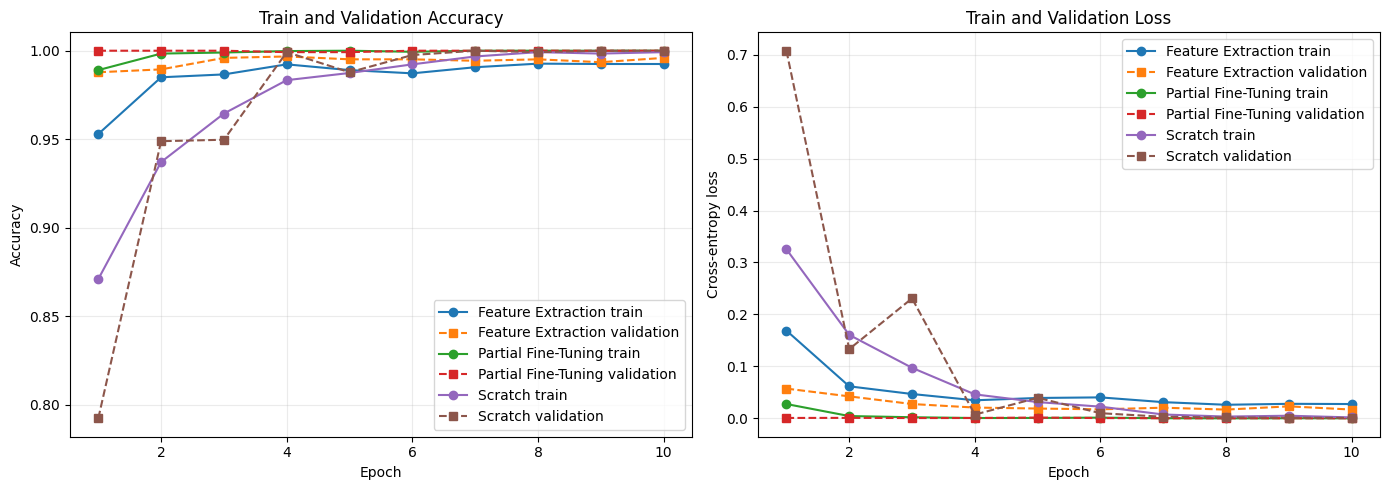

  0%|          | 0/39 [00:00<?, ?it/s]

Best model: Partial Fine-Tuning
Loss validation: 0.0009 | akurasi: 1.0000 | F1: 1.0000
              precision    recall  f1-score   support

      Durian       1.00      1.00      1.00       662
      Papaya       1.00      1.00      1.00       570

    accuracy                           1.00      1232
   macro avg       1.00      1.00      1.00      1232
weighted avg       1.00      1.00      1.00      1232



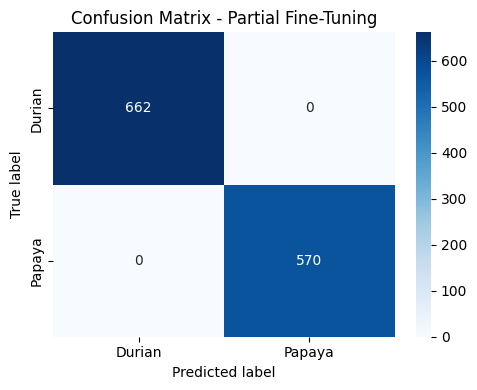

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for result in experiments:
    history = result['history']
    axes[0].plot(history['epoch'], history['train_acc'], marker='o', label=f"{result['name']} train")
    axes[0].plot(history['epoch'], history['val_acc'], marker='s', linestyle='--', label=f"{result['name']} validation")
    axes[1].plot(history['epoch'], history['train_loss'], marker='o', label=f"{result['name']} train")
    axes[1].plot(history['epoch'], history['val_loss'], marker='s', linestyle='--', label=f"{result['name']} validation")
axes[0].set(xlabel='Epoch', ylabel='Accuracy', title='Akurasi train dan validation')
axes[1].set(xlabel='Epoch', ylabel='Loss cross-entropy', title='Loss train dan validation')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'accuracy_curve.png', dpi=160)
plt.show()

best_result = next(result for result in experiments if result['name'] == comparison.iloc[0]['name'])
criterion = nn.CrossEntropyLoss()
val_loss, val_acc, y_true, y_pred = run_epoch(best_result['model'], val_loader, criterion)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
print(f"Best model: {best_result['name']}")
print(f'Loss validation: {val_loss:.4f} | akurasi: {val_acc:.4f} | F1: {f1:.4f}')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title(f'Confusion Matrix - {best_result["name"]}')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=160)
plt.show()

## 8. Latensi inference dan artefak reproducibility

In [8]:
def measure_latency(model, dataloader, warmup=10, runs=100):
    model.eval()
    images, _ = next(iter(dataloader))
    images = images[:1].to(device)
    with torch.inference_mode():
        for _ in range(warmup):
            _ = model(images)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        started = time.perf_counter()
        for _ in range(runs):
            _ = model(images)
        if device.type == 'cuda':
            torch.cuda.synchronize()
    return (time.perf_counter() - started) * 1000 / runs

latency_ms = measure_latency(best_result['model'], val_loader)
comparison.loc[comparison['name'] == best_result['name'], 'inference_latency_ms_per_image'] = latency_ms
comparison.to_csv(RESULTS_DIR / 'comparison.csv', index=False)

config = {
    'seed': SEED, 'batch_size': BATCH_SIZE, 'epochs': EPOCHS, 'validation_fraction': VAL_FRACTION,
    'dataset_root': str(DATASET_ROOT), 'group_mapping_path': str(GROUP_MAPPING_PATH),
    'class_to_idx': class_to_idx, 'device': str(device),
}
with open(RESULTS_DIR / 'config.json', 'w') as file:
    json.dump(config, file, indent=2)

torch.save(best_result['model'].state_dict(), RESULTS_DIR / 'best_resnet18.pt')
print(f'Latensi inference: {latency_ms:.2f} ms/citra')
print(f'Artifacts saved in: {RESULTS_DIR.resolve()}')
display(comparison)

Latensi inference: 3.16 ms/citra
Artifacts saved in: /kaggle/working/results


,name,strategy,best_val_accuracy,best_epoch,training_time_seconds,inference_latency_ms_per_image
0,Partial Fine-Tuning,partial_fine_tuning,1.000000,1,788.661416,3.157388
1,Scratch,scratch,1.000000,7,857.647742,NaN
2,Feature Extraction,feature_extraction,0.996753,4,771.498363,NaN


## 9. Visualisasi dataset

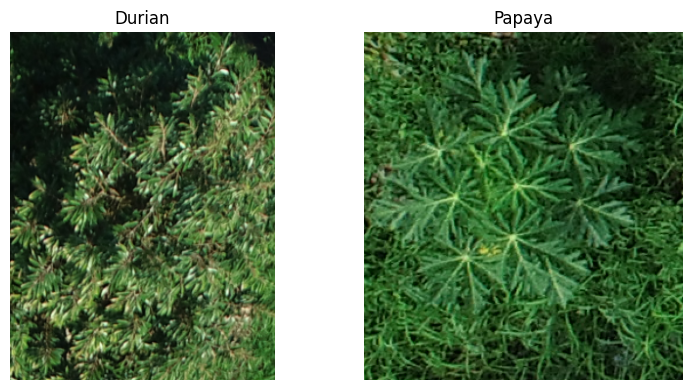

In [10]:
## Visualisasi dataset
fig, axes = plt.subplots(1, len(class_names), figsize=(8, 4))
for axis, class_name in zip(np.atleast_1d(axes), class_names):
    sample_path = train_df.loc[train_df['label_name'] == class_name, 'path'].iloc[0]
    with Image.open(sample_path) as image:
        axis.imshow(image.convert('RGB'))
    axis.set_title(class_name)
    axis.axis('off')
plt.tight_layout()
plt.show()

## 10. Blind test: 20 citra per kelas

Gambar blind test dipisahkan sebelum pembagian data train/validation. Nama file dianonimkan, dan model hanya menerima tensor citra tanpa label atau nama kelas. Label sebenarnya hanya digunakan setelah prediksi selesai untuk menghitung skor evaluasi internal.

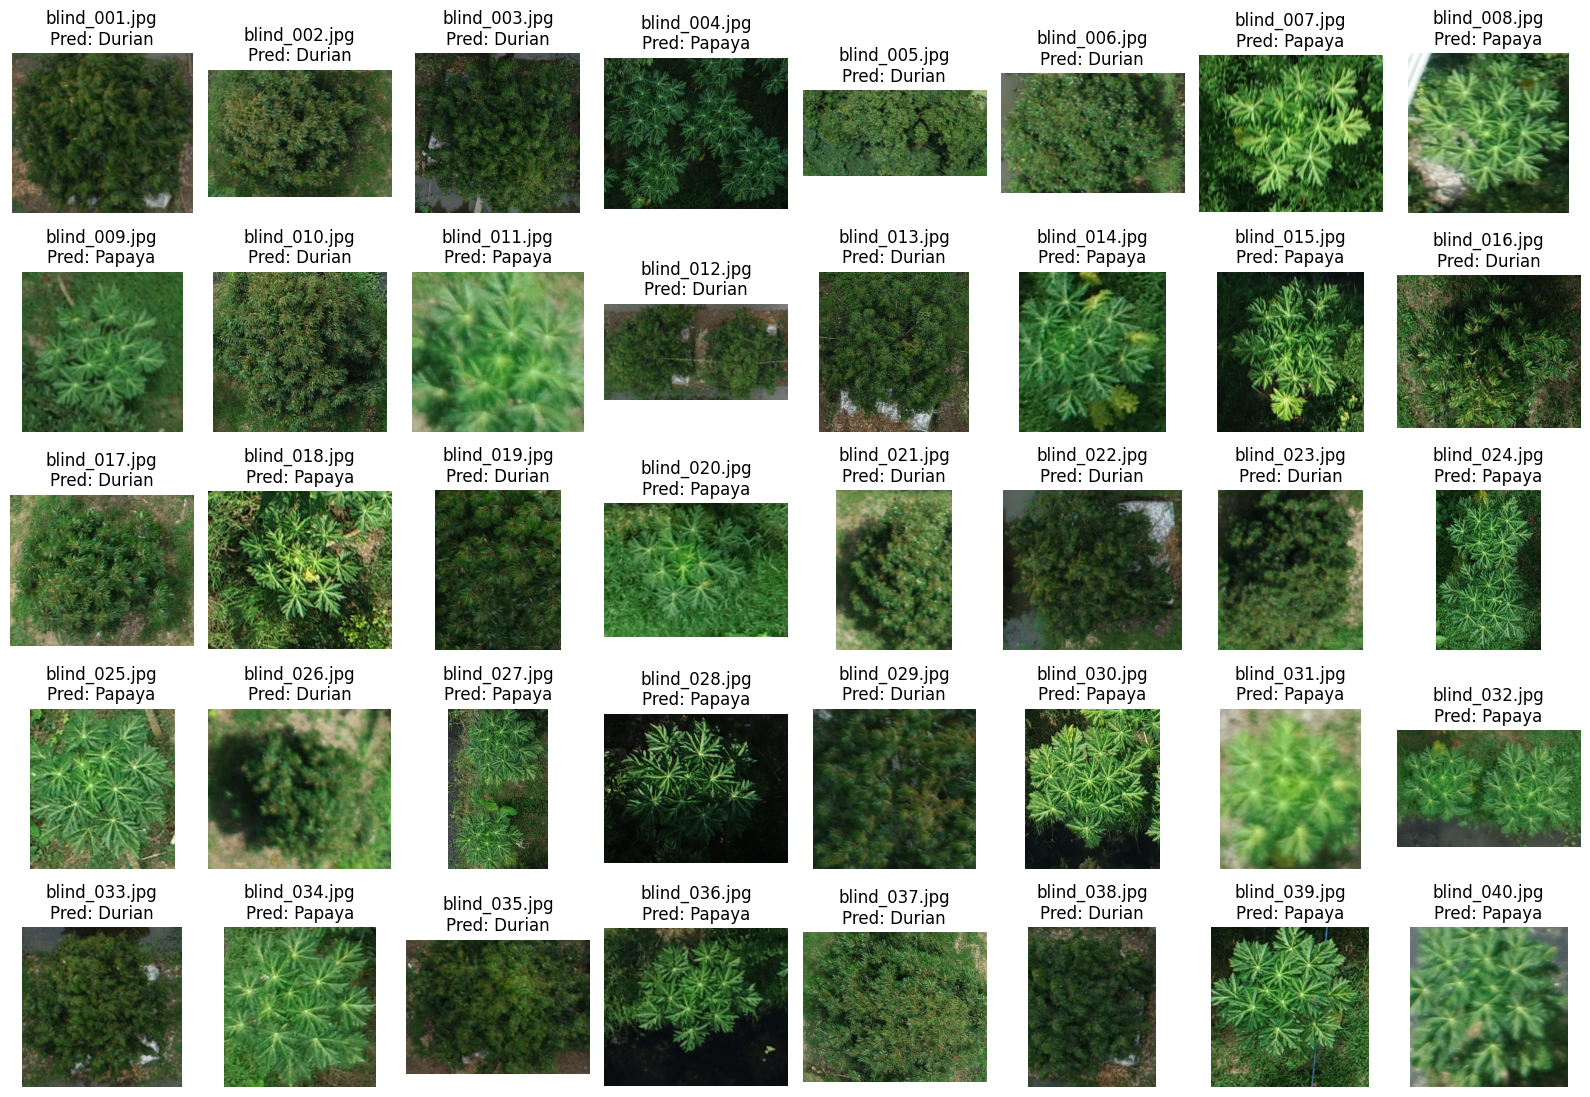

Blind test accuracy (internal evaluation): 1.0000
Blind test images saved without class names: /kaggle/working/results/blind_test_images


In [9]:
blind_test_df = blind_test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
BLIND_TEST_DIR = RESULTS_DIR / 'blind_test_images'
BLIND_TEST_DIR.mkdir(parents=True, exist_ok=True)
blind_paths = []
for index, row in blind_test_df.iterrows():
    blind_path = BLIND_TEST_DIR / f'blind_{index + 1:03d}.jpg'
    with Image.open(row['path']) as image:
        image.convert('RGB').save(blind_path, format='JPEG', quality=95)
    blind_paths.append(blind_path)

best_model = best_result['model']
best_model.eval()
blind_inputs = []
blind_images = []
for blind_path in blind_paths:
    with Image.open(blind_path) as image:
        rgb_image = image.convert('RGB')
        blind_images.append(rgb_image.copy())
        blind_inputs.append(valid_transform(rgb_image))

with torch.inference_mode():
    blind_logits = best_model(torch.stack(blind_inputs).to(device))
    blind_predictions = blind_logits.argmax(dim=1).cpu().numpy()

# Tampilkan hanya nama file yang sudah dianonimkan dan prediksi; label sebenarnya tidak ditampilkan.
fig, axes = plt.subplots(5, 8, figsize=(16, 11))
for axis, image, index, prediction in zip(axes.flat, blind_images, range(len(blind_images)), blind_predictions):
    axis.imshow(image)
    axis.set_title(f'blind_{index + 1:03d}.jpg\nPred: {class_names[prediction]}')
    axis.axis('off')
plt.tight_layout()
plt.show()

# Ini hanya untuk evaluasi internal; label ini tidak pernah diberikan ke model.
blind_accuracy = accuracy_score(blind_test_df['label'], blind_predictions)
print(f'Blind test accuracy (internal evaluation): {blind_accuracy:.4f}')
print(f'Blind test images saved without class names: {BLIND_TEST_DIR.resolve()}')